In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData
from scipy.stats import chi2 as chi2_dist

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

correction = 0.01

In [8]:
d = np.genfromtxt("./data.csv", delimiter=",", names=True, dtype=float)
T, L, th = d["T"], d["L"]-correction, d["theta"]
sT, sL, sth = d["sigma_T"], d["sigma_L"], d["sigma_theta"]
R, sR = 0.028575, 0.0001
N = T.size

In [9]:
f  = 1 + th**2/16 + 11*th**4/3072
df = th/8 + 11*th**3/768

B  = L + 0.4 * R**2 / L
A  = B * f**2
y, sy = T**2, 2*T*sT

dA_dL  = (1 - 0.4 * R**2 / L**2) * f**2
dA_dR  = (0.8 * R / L) * f**2
dA_dth = B * 2 * f * df
sigma_A2 = (dA_dL*sL)**2 + (dA_dR*sR)**2 + (dA_dth*sth)**2
sigma_A  = np.sqrt(sigma_A2)

In [10]:
odr = ODR(RealData(A, y, sx=sigma_A, sy=sy),
          Model(lambda p, x: p[0]*x), beta0=[4.0])
out = odr.run()

s, sigma_s = out.beta[0], out.sd_beta[0]
g_hat   = 4*np.pi**2 / s
sigma_g = 4*np.pi**2 * sigma_s / s**2

seff  = np.sqrt(sy**2 + s**2 * sigma_A2)
resid = y - s*A
dof   = N - 1
chi2  = np.sum((resid/seff)**2)
pval  = 1 - chi2_dist.cdf(chi2, dof)

print(f"g = {g_hat:.6f} +/- {sigma_g:.6f} m/s^2")
print(f"s = {s:.8f} +/- {sigma_s:.8f}")
print(f"chi2/dof = {chi2:.3f}/{dof} = {chi2/dof:.3f}, p = {pval:.4f}")

g = 9.798987 +/- 0.004551 m/s^2
s = 4.02882636 +/- 0.00187114
chi2/dof = 13.804/6 = 2.301, p = 0.0319


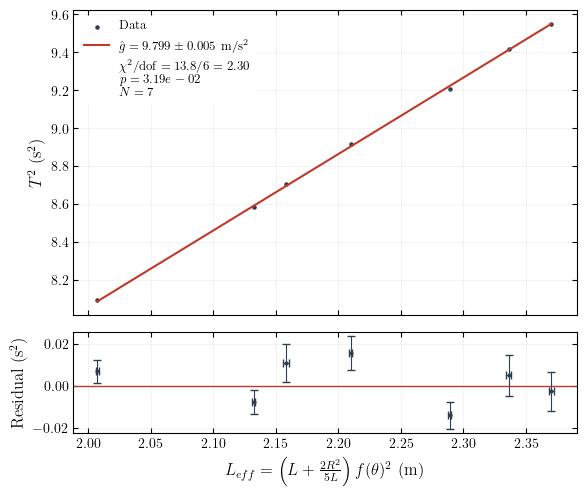

In [11]:
c_data, c_fit, c_band, c_resid = '#2c3e50', '#c0392b', '#e74c3c', '#2980b9'
markersize=2
precision=3

Af = np.linspace(min(A), max(A), 100)
s_lo = 4*np.pi**2 / (g_hat + sigma_g)
s_hi = 4*np.pi**2 / (g_hat - sigma_g)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 5.5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

# --- Fit plot ---
# ax1.fill_between(Af, s_lo*Af, s_hi*Af, color=c_band, alpha=0.15, label=r'$\pm 1\sigma_g$ band')
ax1.scatter(A, y, color=c_data,s=5, lw=1,  label='Data')
ax1.plot(Af, s*Af, '-', color=c_fit, lw=1.5, label=rf'$\hat{{g}} = {g_hat:.3f} \pm {sigma_g:.3f}$ m/s$^2$')


legend_text = (rf'$\chi^2/\mathrm{{dof}} = {chi2:.1f}/{dof} = {chi2/dof:.2f}$' '\n'
               rf'$p = {pval:.2e}$' '\n'
               rf'$N = {N}$')

ax1.set(ylabel=r'$T^2$ (s$^2$)')

ax1.plot([], [], ' ', label=legend_text)

ax1.legend(framealpha=0.9, edgecolor='none', fontsize=9)
ax1.grid(alpha=0.2, lw=0.5)

# --- Residual plot ---
ax2.axhline(0, color=c_fit, lw=1)
ax2.errorbar(A, resid, xerr=sigma_A, yerr=seff, fmt='o', color=c_data,
             capsize=3, ms=markersize, lw=1, elinewidth=0.8,)
ax2.set(xlabel=r'$L_{eff}= \left(L + \frac{2R^2}{5L}\right) f(\theta)^2$ (m)',
        ylabel=r'Residual (s$^2$)')
ax2.grid(alpha=0.2, lw=0.5)

for ax in (ax1, ax2):
    ax.tick_params(direction='in', top=True, right=True)

plt.savefig("plot.png", dpi=300, bbox_inches='tight')